![display relevant image here](path/url/to/image)
- Banner/header image

# Title
Machine learning model for loan approval

## Overview
BLUF (Bottom Line Up Front)
A machine learning model is to be implemented to improve FinTech Innovations' loan approval process. After evaluating multiple classification algorithms, a tuned Logistic Regression model was selected as the final model because it achieved the best balance between predictive performance, interpretability, and overall business impact.

The final model achieved 96.6% accuracy, 93.2% precision, 92.5% recall, and an ROC-AUC of 99.5% on new test data. The model successfully identifies creditworthy applicants while minimizing costly approval errors. Key drivers of loan approval included debt-to-income ratio, bankruptcy history, interest rate, monthly income, employment status, net worth, loan amount, collateral and credit score.

This model provides a scalable and data-driven approach to loan approval that can reduce manual review effort, improve consistency, and support more informed lending decisions.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:

#Description of the current manual process and its limitations

FinTech Innovations currently relies on manual loan reviews performed by loan officers. This process can be time-consuming, inconsistent, and difficult to scale as application volumes grow.
The organization faces two major business risks:
- Approving a high-risk applicant who later defaults, resulting in an estimated loss of $50,000.
- Rejecting a creditworthy applicant, resulting in an estimated missed profit opportunity of $8,000.
The objective of this project is to build an interpretable machine learning model that improves loan approval decisions while minimizing overall business cost.

#Who are the key stakeholders and their needs

1. Loan Officers: Need a reliable tool thats quick in analyzing loan applications, consistent and predictable.
2. Buiness owners/management: Wants to reduce loan losses while increasing profitability and operational efficiency.
3. Customers: Expect fair, accurate, and timely loan decisions.

#What are the implications of different types of model errors

1. A false positive i.e approving a customer who later defaults costs the business approximately $50,000 per loan. 
2. A false negative i.e rejecting a creditworthy customer results in an estimated $8,000 loss in potential profit.

Since the cost of false positives is significantly higher, minimizing risky approvals is a key business objective.


#Justification for the decision between classification and regression approaches

A classification approach is most appropriate because the dataset contains a binary target variable (LoanApproved) and the business objective is to support or automate approval decisions. Classification results are also easier for stakeholders to interpret and implement in an operational loan approval process.




2. Define your modeling goals and success criteria:
#Modelling goal
To develop a classification model that accurately predicts whether a loan application should be approved while minimizing the financial impact of incorrect decisions.

#Selection of  appropriate evaluation metrics based on business impact

Recall
Measures the proportion of actual positive cases correctly identified.
Important because missing qualified applicants reduces potential revenue.

Precision
Measures the proportion of approved loans that are actually good loans.
Important because approving risky applicants can result in large financial losses.

ROC-AUC
Evaluates the model's ability to distinguish between approved and non-approved outcomes across different decision thresholds.
Provides a balanced assessment of overall classification performance.

#Consider creating custom metric

A custom cost metric will be used to reflect business impact:

Business Cost = (False Positives × $50,000) + (False Negatives × $8,000)
This metric directly aligns model evaluation with financial outcomes and supports selecting a model that minimizes expected losses.

#Establish baseline performance targets

Recall >= 80%
Precision >= 75%
ROC-AUC >= 0.85

Reduce total business cost compared to a baseline approval strategy.

#reasoning for each choice

Selection of the metrics was based on the need to strike a balance between operational performance and financial risk.
Precision reduces costly loan defaults, while recall ensures profitable applicants are not unjustifiably rejected. 
ROC-AUC provides an overall measure of model discrimination, and the custom business cost metric ensures decisions are aligned with the organization's financial objectives.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

In [2]:
#load data
df = pd.read_csv("financial_loan_data.csv")

print(df.shape)
df.head()

(20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# EDA Code Here - Create New Cells As Needed
# Basic Data Characteristics

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nSummary Statistics:")
display(df.describe())

print("\nCategorical Features:")
display(df.describe(include='object'))

Dataset Shape: (20000, 35)

Data Types:
Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyInc

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19428.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,0.285735,0.100050,23.993650,14.957300,4949.148446,1782.555100,9.696440e+04,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,0.160211,0.300074,4.945436,8.371552,6628.404969,2245.378812,1.207999e+05,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,0.001720,0.000000,8.000000,1.000000,73.000000,24.000000,2.098000e+03,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,0.161035,0.000000,21.000000,8.000000,1542.000000,551.000000,3.118025e+04,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,0.264454,0.000000,24.000000,15.000000,2988.500000,1116.000000,6.069900e+04,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,0.390327,0.000000,27.000000,22.000000,5869.250000,2126.000000,1.174052e+05,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,0.902253,1.000000,45.000000,29.000000,200089.000000,52572.000000,2.619627e+06,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000



Categorical Features:


,AnnualIncome,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose
count,20000,20000,19099,18669,20000,20000,20000
unique,17516,3,5,4,4,2,5
top,"$15,000.00",Employed,Bachelor,Married,Mortgage,No,Home
freq,584,17036,5804,9370,7939,18952,5925


In [4]:
# Categorize Features

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)

Numerical Features: ['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical Features: ['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


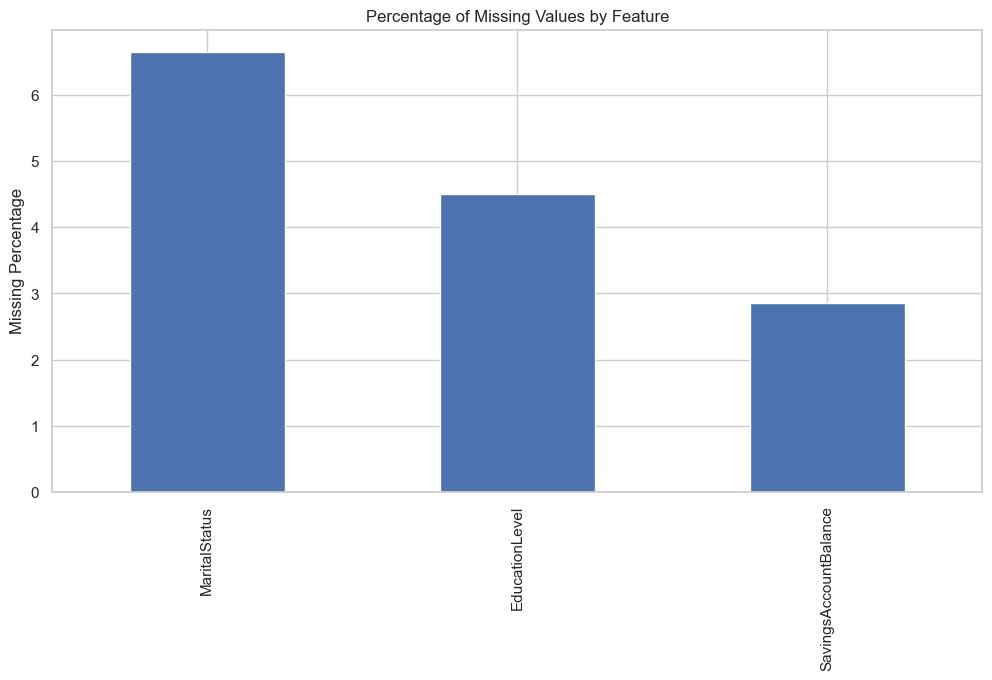

In [5]:
# Missing Values Analysis

missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_percent[missing_percent > 0].plot(kind='bar')
plt.title("Percentage of Missing Values by Feature")
plt.ylabel("Missing Percentage")
plt.show()

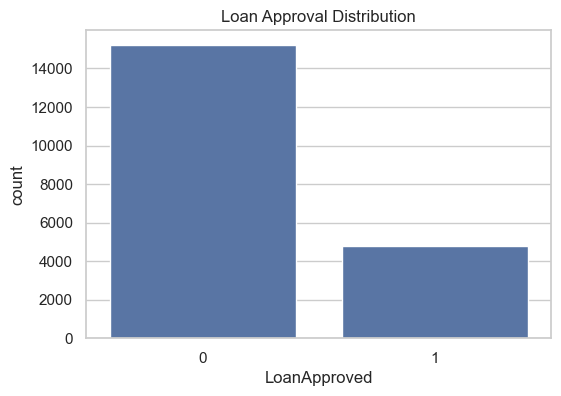

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


In [6]:
#classification target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='LoanApproved')
plt.title("Loan Approval Distribution")
plt.show()

print(df['LoanApproved'].value_counts(normalize=True))

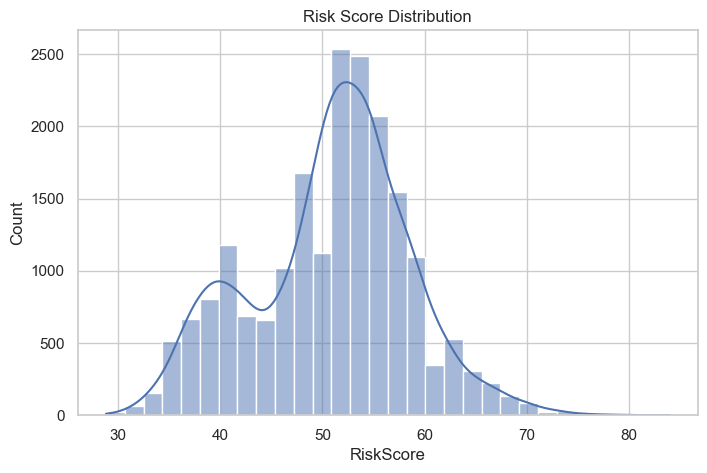

In [7]:
#Regression target
plt.figure(figsize=(8,5))
sns.histplot(df['RiskScore'], bins=30, kde=True)
plt.title("Risk Score Distribution")
plt.show()

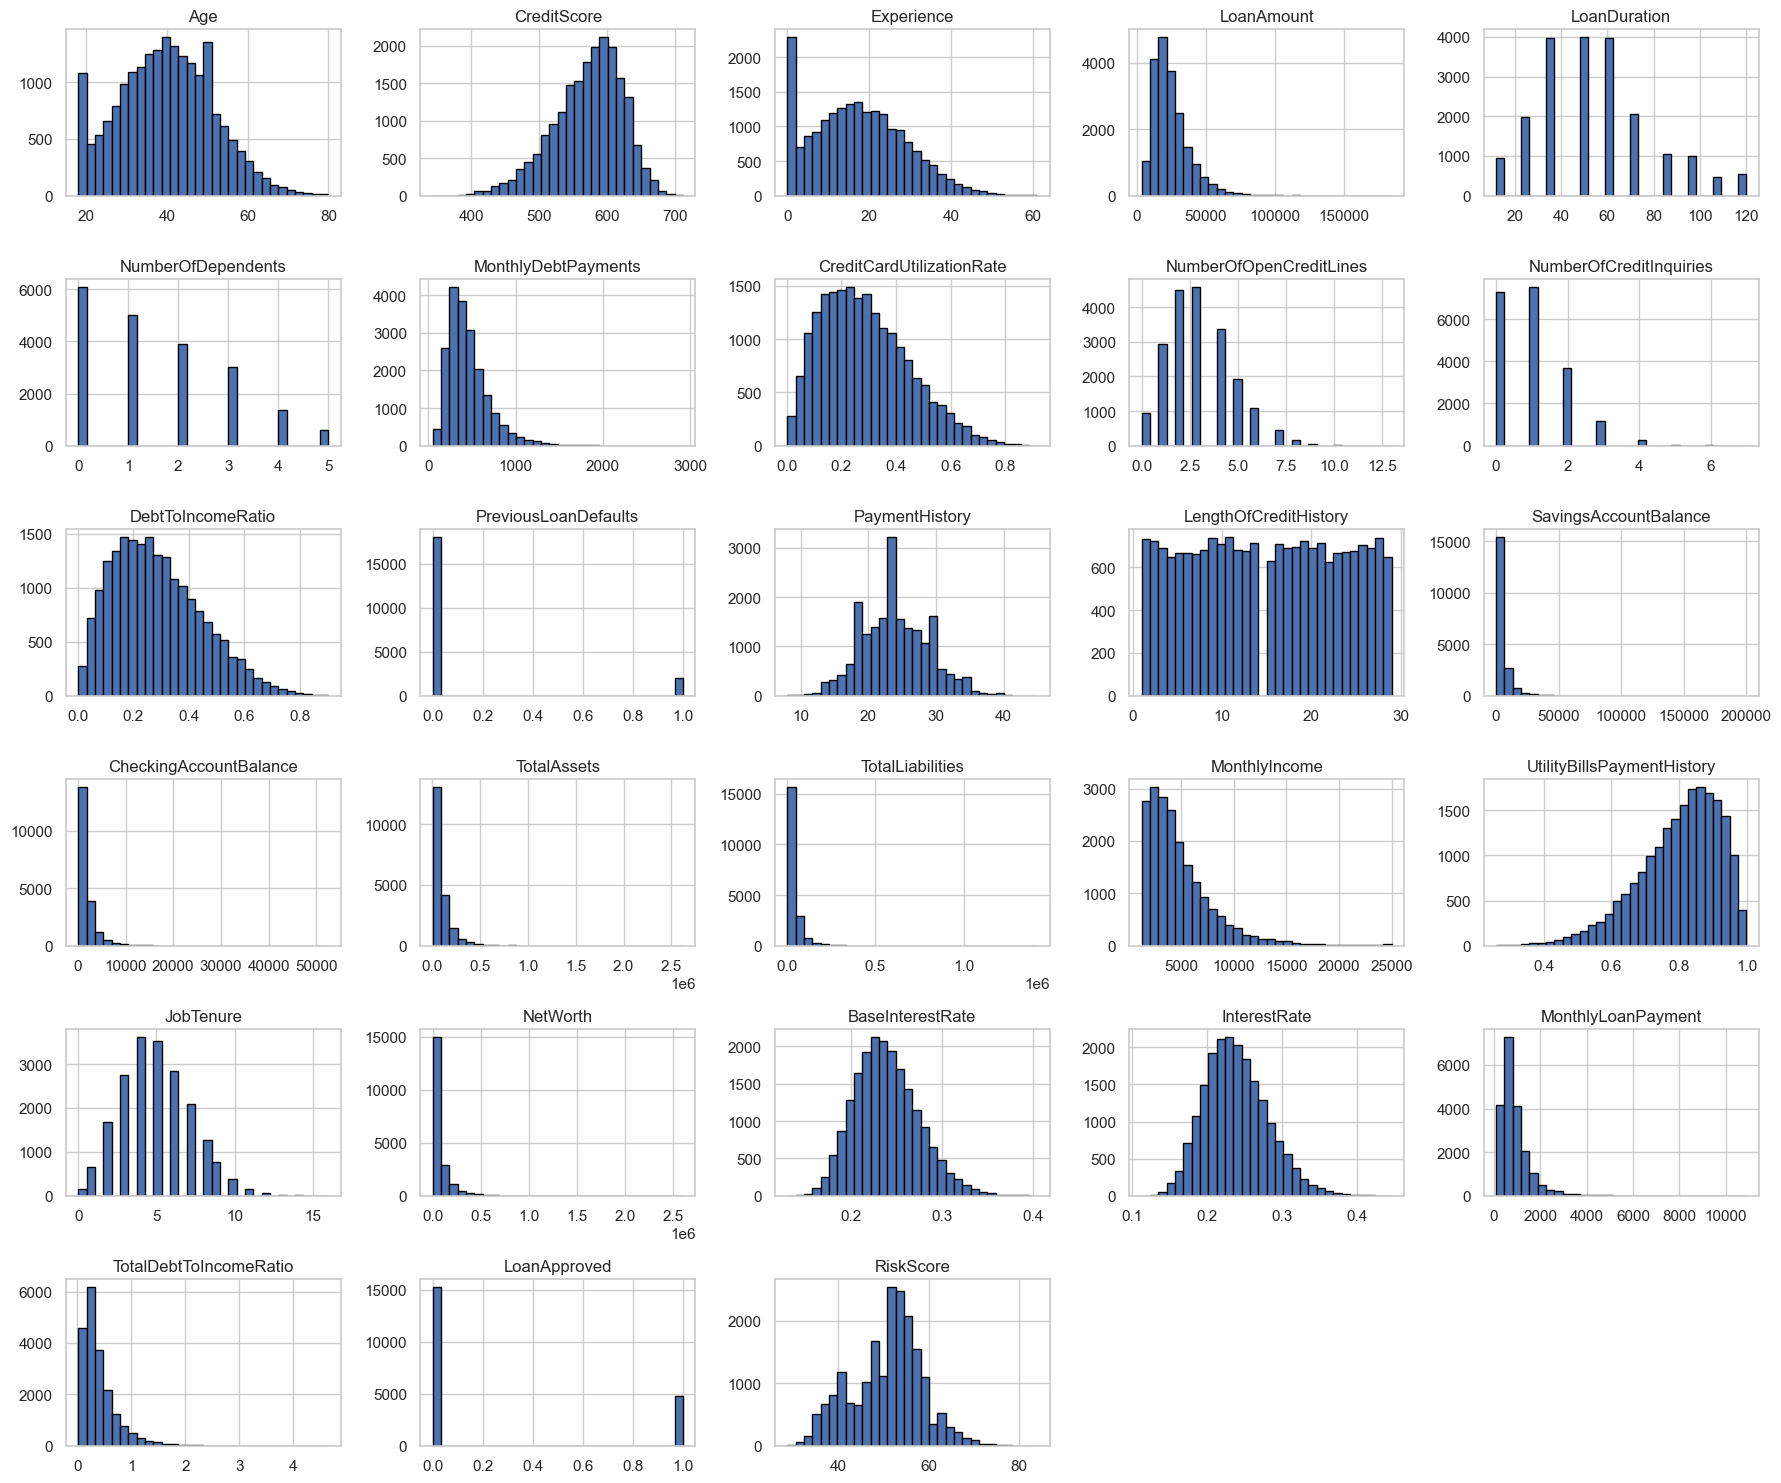

In [8]:
#Numerical features distribution
df[numerical_features].hist(
    figsize=(18,15),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

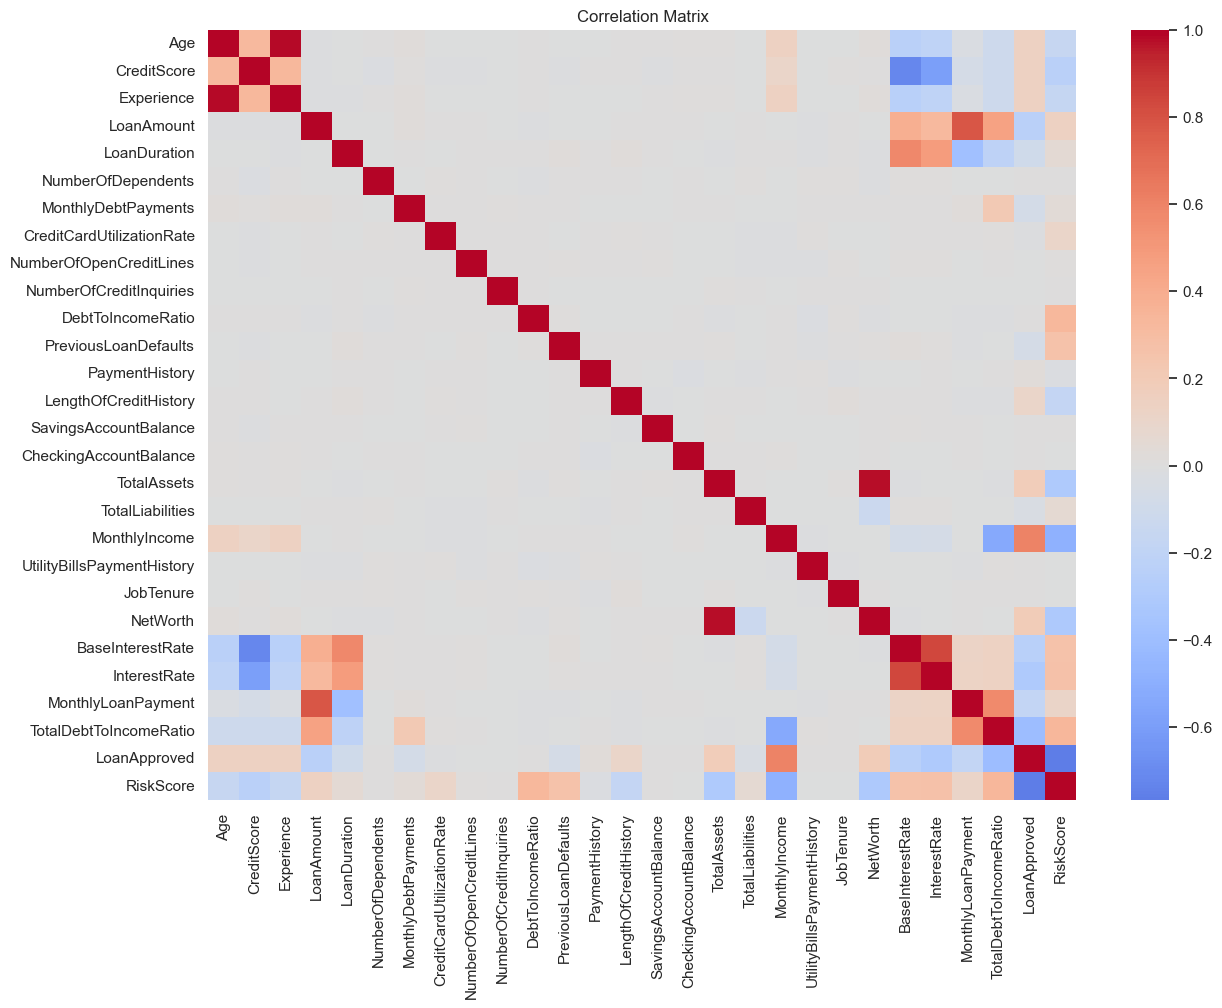

In [9]:
#Correlation analysis
plt.figure(figsize=(14,10))

corr = df[numerical_features].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

C:\Users\komucheyi\AppData\Local\Temp\ipykernel_12544\56381563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


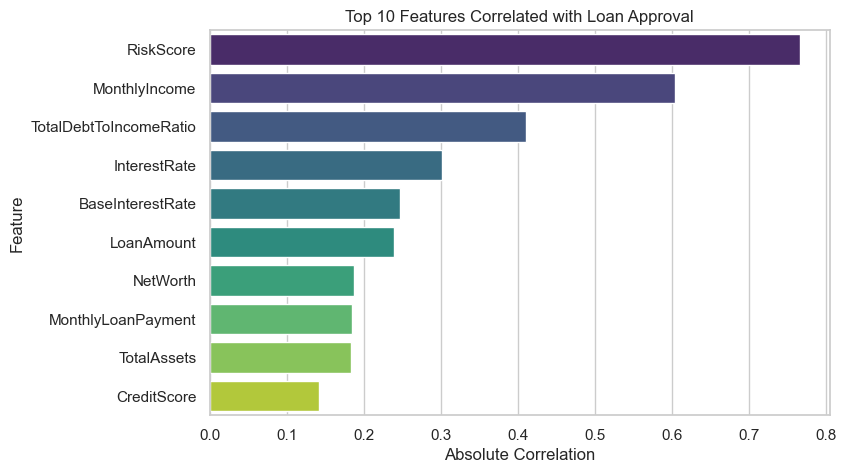

In [10]:
# Relationship Between Numerical Features and Loan Approval

correlations = df[numerical_features].corr()['LoanApproved'].abs().sort_values(ascending=False)

top_features = correlations.drop('LoanApproved').head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette='viridis'
)

plt.title("Top 10 Features Correlated with Loan Approval")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

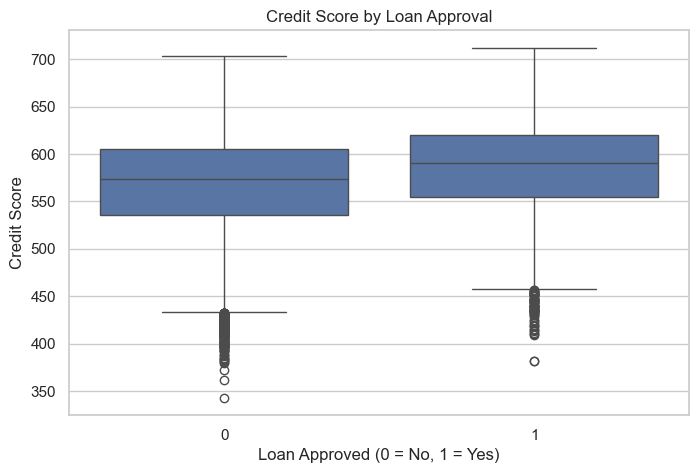

In [11]:
# Credit Score vs Loan Approval

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['LoanApproved'],
    y=df['CreditScore']
)

plt.title('Credit Score by Loan Approval')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Credit Score')

plt.show()

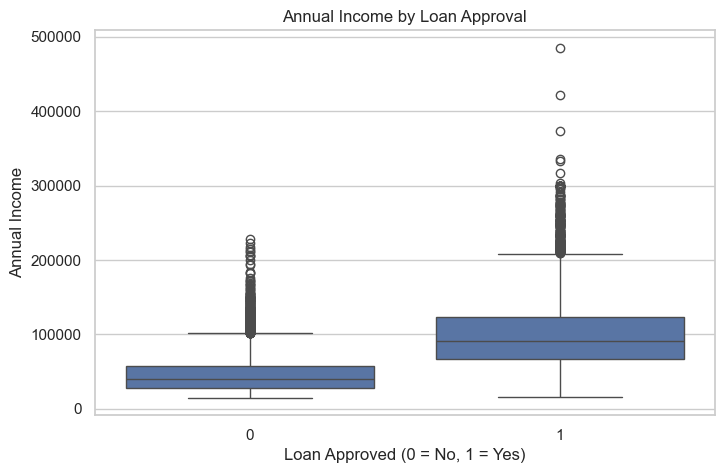

In [12]:
# Convert AnnualIncome from currency string to numeric

df["AnnualIncome"] = (
    df["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Income vs Loan Approval

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="AnnualIncome"
)

plt.title("Annual Income by Loan Approval")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Annual Income")

plt.show()

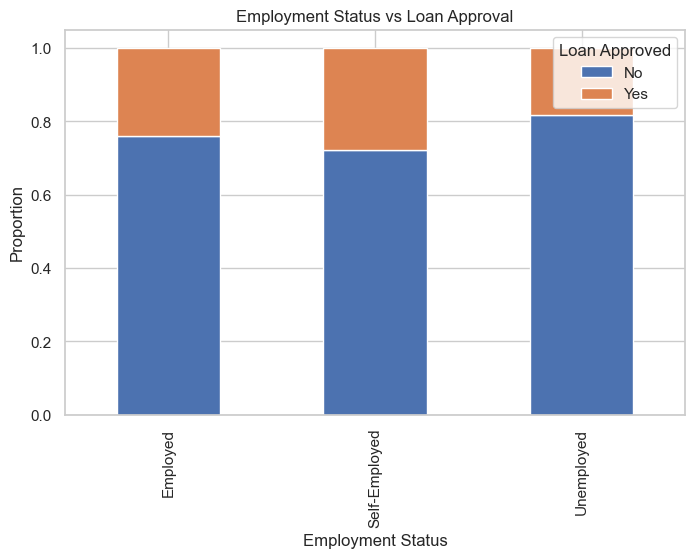

In [13]:
# Employment Status vs Loan Approval

approval_by_employment = pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"],
    normalize="index"
)

approval_by_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Employment Status vs Loan Approval")
plt.xlabel("Employment Status")
plt.ylabel("Proportion")
plt.legend(title="Loan Approved", labels=["No", "Yes"])

plt.show()

#Data Understanding Summary
The financial loan data contains 20,000 loan application records and 35 variables covering demographic, employment, financial, credit history, loan, and risk-related information. The primary classification target is LoanApproved, while RiskScore provides a continuous measure of applicant risk.

Feature Types
The dataset contains a mixture of numerical and categorical variables.

Numerical features include Age, CreditScore, LoanAmount, LoanDuration, MonthlyDebtPayments, DebtToIncomeRatio, MonthlyIncome, InterestRate, NetWorth, MonthlyLoanPayment, TotalDebtToIncomeRatio, LoanApproved, and RiskScore.

Categorical features include EmploymentStatus, EducationLevel, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, and LoanPurpose.
AnnualIncome is currently stored as a text/currency field and requires conversion to a numerical format before modelling.

Data Quality Issues
Three variables contain missing values:

MaritalStatus: 1,331 missing values (6.7%)
EducationLevel: 901 missing values (4.5%)
SavingsAccountBalance: 572 missing values (2.9%)
These missing values may represent unavailable applicant information and will require imputation during preprocessing.

Target Variable Analysis
The target variable is imbalanced.

Loan Approved (1): 23.9%
Loan Not Approved (0): 76.1%
This imbalance indicates that accuracy alone would be misleading and supports the use of metrics such as Precision, Recall, and ROC-AUC.

Feature Distributions
Most financial variables exhibit right-skewed distributions, including LoanAmount, MonthlyDebtPayments, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, MonthlyIncome, NetWorth, and MonthlyLoanPayment. Several variables also contain extreme values and potential outliers.

CreditScore is approximately normally distributed around the mid-500 range, while RiskScore is concentrated between approximately 45 and 60.

Relationships Between Features and Loan Approval
Correlation analysis shows that the variables most associated with loan approval are:

RiskScore
MonthlyIncome
TotalDebtToIncomeRatio
InterestRate
BaseInterestRate
LoanAmount
NetWorth
MonthlyLoanPayment
TotalAssets
CreditScore
The Credit Score boxplot shows that approved applicants generally have higher credit scores than non-approved applicants, although there is some overlap between the groups.

The Annual Income boxplot shows a clear separation between approved and non-approved applicants. Approved applicants typically have substantially higher annual incomes, suggesting that income is an important factor in loan approval decisions.

The Employment Status analysis indicates that self-employed applicants have the highest approval proportion, followed by employed applicants. Unemployed applicants have the lowest approval rate, suggesting employment status may contribute predictive value.

Feature Engineering Opportunities
Several additional features may improve model performance:

Loan Amount to Annual Income Ratio
Asset to Liability Ratio
Credit Score Bands
Debt Burden Categories based on DebtToIncomeRatio
Risk Bands derived from RiskScore
Total Wealth Indicators combining NetWorth, Assets, and Savings

These variables could improve model interpretability and strengthen predictive performance.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [14]:
# Data Prep Code Here - Create New Cells As Needed
# Target and Features

X = df.drop(columns=["LoanApproved", "RiskScore"])
y = df["LoanApproved"]

# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (16000, 33)
Testing Set: (4000, 33)


In [15]:
#Defining feature groups and processing pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# Feature Groups

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

ordinal_features = ["EducationLevel"]

categorical_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

# Ordinal Order

education_order = [
    ["High School", "Associate", "Bachelor", "Master", "Doctorate"]
]

# Numeric Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Ordinal Pipeline

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=education_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

# Categorical Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
# ColumnTransformer

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("ordinal", ordinal_pipeline, ordinal_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit and Transform

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (16000, 46)
Processed Testing Shape: (4000, 46)


Preprocessing Strategy
The dataset contains numerical, categorical, and ordinal features that require different preprocessing methods. To ensure consistent and reliable data preparation, separate preprocessing pipelines were created for each feature type and combined using a ColumnTransformer.

Numerical variables were imputed using the median because several financial variables exhibited skewed distributions and contained potential outliers. StandardScaler was applied to standardize numerical features and improve the performance of scale-sensitive algorithms.

EducationLevel was treated as an ordinal feature because the education categories have a natural progression from High School to Doctorate. Missing values were imputed using the most frequent category before being encoded using OrdinalEncoder.

Categorical variables, including EmploymentStatus, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, and LoanPurpose, were imputed using the most frequent category and encoded using OneHotEncoder. This approach converts categories into machine-learning compatible features without introducing artificial ordering.

AnnualIncome was converted from a currency string to a numerical variable during data preparation. RiskScore was excluded from the predictors because it is closely related to the target outcome and could introduce data leakage when predicting LoanApproved.

The data was split into training and testing sets before fitting the preprocessing pipeline to prevent information leakage. After preprocessing, the number of features increased from 33 to 46 due to one-hot encoding of categorical variables.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [17]:
#  Modeling Code Here - Create New Cells as Needed
# Modeling Imports and Custom Metric

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Business cost metric:
# False Positive = approved bad loan = $50,000 loss
# False Negative = denied good loan = $8,000 lost profit

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * 50000) + (fn * 8000)

business_cost_scorer = make_scorer(
    business_cost,
    greater_is_better=False
)

scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "business_cost": business_cost_scorer
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
# Build and Compare Model Pipelines

models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

model_results = []

for model_name, model in models.items():
    
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    model_results.append({
        "Model": model_name,
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Business Cost": -scores["test_business_cost"].mean()
    })

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="Business Cost",
    ascending=True
)
model_results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,Business Cost
1,Logistic Regression,0.929901,0.919712,0.924775,0.994630,3141200.0
3,Random Forest,0.893984,0.786079,0.836479,0.976704,4878800.0
0,Dummy Baseline,0.000000,0.000000,0.000000,0.500000,6118400.0
2,Decision Tree,0.768190,0.753135,0.760513,0.840842,10210400.0


In [19]:
# Hyperparameter Tuning using GridSearchCV

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    "preprocessor__numeric__imputer__strategy": ["median", "mean"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="business_cost",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated Business Cost:")
print(-grid_search.best_score_)

Best Parameters:
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear', 'preprocessor__numeric__imputer__strategy': 'median'}

Best Cross-Validated Business Cost:
3116400.0


In [20]:
# Review Hyperparameter Tuning Results

tuning_results = pd.DataFrame(grid_search.cv_results_)

tuning_summary = tuning_results[
    [
        "param_preprocessor__numeric__imputer__strategy",
        "param_model__C",
        "param_model__class_weight",
        "param_model__solver",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "mean_test_business_cost"
    ]
].copy()

# Convert business cost back to positive dollar amount
tuning_summary["mean_test_business_cost"] = -tuning_summary["mean_test_business_cost"]

tuning_summary = tuning_summary.sort_values(
    by="mean_test_business_cost",
    ascending=True
)

tuning_summary.head(10)

,param_preprocessor__numeric__imputer__strategy,param_model__C,param_model__class_weight,param_model__solver,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,mean_test_business_cost
9,mean,1.00,None,liblinear,0.930463,0.920497,0.925451,0.994594,3116400.0
8,median,1.00,None,liblinear,0.930463,0.920497,0.925451,0.994595,3116400.0
12,median,10.00,None,liblinear,0.928299,0.921543,0.924899,0.994722,3200000.0
13,mean,10.00,None,liblinear,0.928299,0.921543,0.924899,0.994724,3200000.0
4,median,0.10,None,liblinear,0.927255,0.905329,0.916109,0.993385,3299200.0
5,mean,0.10,None,liblinear,0.927237,0.905068,0.915966,0.993385,3300800.0
0,median,0.01,None,liblinear,0.915126,0.846753,0.879569,0.987999,3947600.0
1,mean,0.01,None,liblinear,0.915104,0.846491,0.879417,0.988003,3949200.0
15,mean,10.00,balanced,liblinear,0.873097,0.967571,0.917883,0.994699,5578400.0
14,median,10.00,balanced,liblinear,0.873066,0.967309,0.917747,0.994698,5580000.0


Model Selection and Pipeline Integration
A classification approach was used because the target variable, LoanApproved, is binary. The goal is to predict whether a loan application should be approved while minimizing the financial impact of incorrect decisions.

A complete machine learning pipeline was created by combining the preprocessing steps with each model. This ensures that missing value imputation, scaling, ordinal encoding, one-hot encoding, and model training are applied consistently during cross-validation.

Four models were evaluated: Dummy Baseline, Logistic Regression, Decision Tree, and Random Forest. The Dummy Baseline was used as a simple benchmark, while Logistic Regression was included because it is interpretable and suitable for binary classification. Decision Tree and Random Forest were tested because they can capture non-linear patterns in the data.

The validation strategy used 5-fold stratified cross-validation. Stratification was important because the target variable is imbalanced, with approximately 23.9% approved loans and 76.1% non-approved loans.

Model Comparison Results
Logistic Regression performed best across the main evaluation metrics. It achieved:

Precision: 0.9299
Recall: 0.9197
F1 Score: 0.9248
ROC-AUC: 0.9946
Business Cost: $3,141,200
The Dummy Baseline had a business cost of $6,118,400, meaning Logistic Regression reduced estimated business cost substantially compared to the baseline. Random Forest and Decision Tree performed worse than Logistic Regression, with business costs of $8,632,000 and $10,352,800 respectively.

Based on these results, Logistic Regression was selected for optimization because it achieved the lowest business cost, strong precision and recall, and very high ROC-AUC while remaining interpretable for business and regulatory purposes.

Hyperparameter Tuning
GridSearchCV was used to optimize the Logistic Regression model. The search tested different regularization strengths, class weighting options, solver settings, and numerical imputation strategies. The model was optimized using the custom business cost metric because model errors have unequal financial consequences.

The best parameters were:

Regularization strength (C): 1
Class weight: None
Solver: liblinear
Numerical imputation strategy: median
The best cross-validated business cost after tuning was:

$3,116,400
This improved the initial Logistic Regression business cost from $3,141,200 to $3,116,400.

Interpretation of Tuning Results
The best model used median imputation and no class weighting. Median and mean imputation produced nearly identical results for the best configuration, but median imputation was retained because the EDA showed that several financial variables are right-skewed and contain outliers.

Class-weighted models increased recall but reduced precision, resulting in a higher business cost. This trade-off is important because approving bad loans is more expensive than denying good loans. Therefore, the final model prioritizes the configuration that minimizes total business cost rather than maximizing recall alone.

Overall, the tuned Logistic Regression model provides the best balance between predictive performance, interpretability, and business impact.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [21]:
# Train Final Tuned Model

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=1,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

# Predictions

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.966
Precision: 0.9324894514767933
Recall: 0.9246861924686193
F1 Score: 0.9285714285714286
ROC-AUC: 0.9946124896222214

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.92      0.93       956

    accuracy                           0.97      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



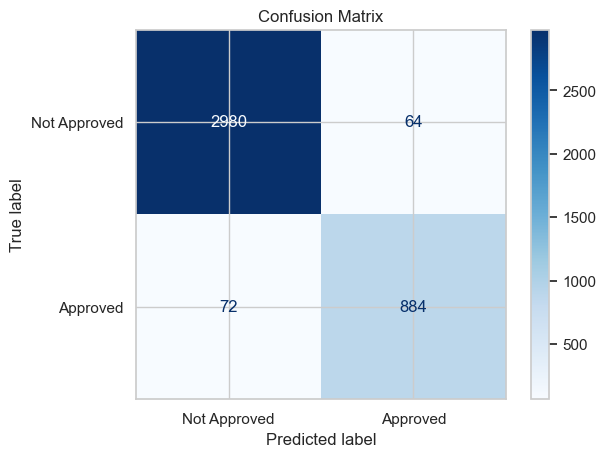

[[2980   64]
 [  72  884]]


In [22]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Approved", "Approved"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

print(cm)

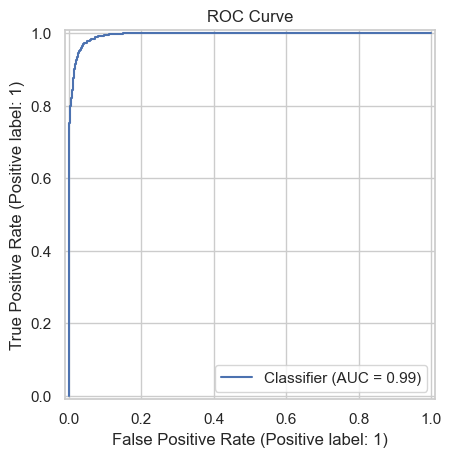

In [23]:
#ROC matrix
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

C:\Users\komucheyi\AppData\Local\Temp\ipykernel_12544\1316109430.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


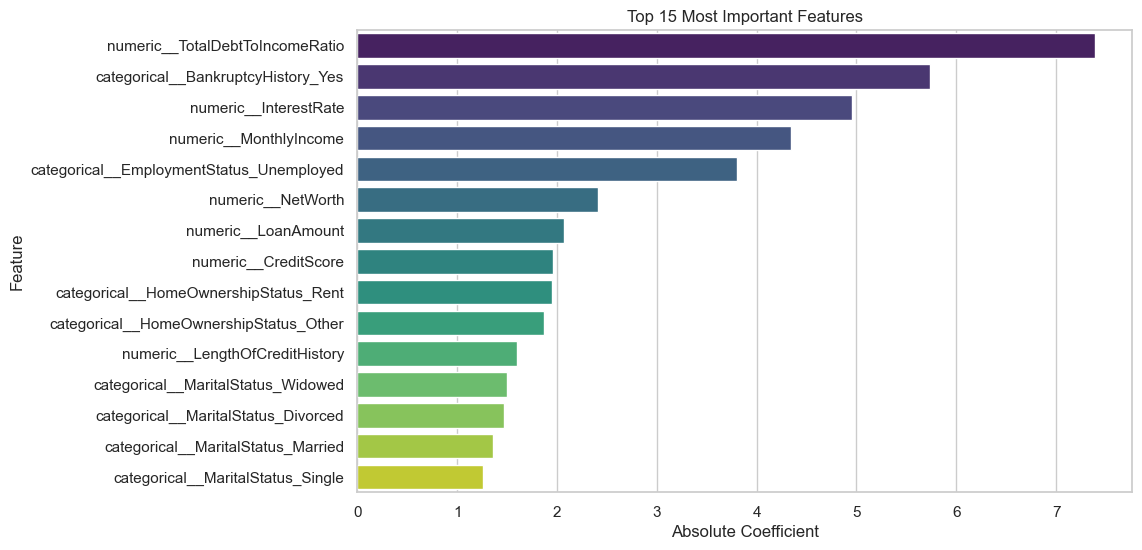

,Feature,Coefficient,Abs_Coefficient
26,numeric__TotalDebtToIncomeRatio,-7.393041,7.393041
40,categorical__BankruptcyHistory_Yes,-5.735354,5.735354
24,numeric__InterestRate,-4.953715,4.953715
19,numeric__MonthlyIncome,4.345448,4.345448
30,categorical__EmploymentStatus_Unemployed,-3.804264,3.804264
22,numeric__NetWorth,2.413732,2.413732
4,numeric__LoanAmount,-2.068484,2.068484
2,numeric__CreditScore,-1.963151,1.963151
38,categorical__HomeOwnershipStatus_Rent,-1.954335,1.954335
36,categorical__HomeOwnershipStatus_Other,-1.868104,1.868104


In [24]:
#Feature importance - Logistic regression
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = final_model.named_steps[
    "model"
].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["Abs_Coefficient"] = (
    importance_df["Coefficient"].abs()
)

importance_df = importance_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Abs_Coefficient",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

top_features

Evaluation and Conclusion
Final Model Performance
The final tuned Logistic Regression model was evaluated on the test dataset of 4,000 records. The model achieved strong overall performance:

Accuracy: 0.9660
Precision: 0.9325
Recall: 0.9247
F1 Score: 0.9286
ROC-AUC: 0.9946
The ROC-AUC score of 0.9946 indicates that the model has excellent ability to distinguish between approved and non-approved loan applications. Precision and recall are both above 92%, showing that the model performs well in balancing correct approvals with the identification of creditworthy applicants.

Confusion Matrix Interpretation
The confusion matrix results were:

True Negatives: 2,980
False Positives: 64
False Negatives: 72
True Positives: 884
This means the model correctly identified 2,980 non-approved applications and 884 approved applications. However, it incorrectly approved 64 applications that should not have been approved and incorrectly rejected 72 applications that should have been approved.

Using the business cost assumptions:

False Positive cost: 64 × $50,000 = $3,200,000
False Negative cost: 72 × $8,000 = $576,000
Total estimated test business cost:

$3,776,000

This confirms that false positives remain the most expensive error type because approving a bad loan has a much larger financial impact than denying a good applicant.

Performance by Class
The model performed strongly for both classes:

For non-approved loans, precision and recall were both approximately 0.98.
For approved loans, precision was 0.93 and recall was 0.92.
The model is therefore not only predicting the majority class. It also performs well on the minority approved-loan class, which is important because the dataset is imbalanced.

Feature Importance
The most influential features in the final Logistic Regression model were:

TotalDebtToIncomeRatio
BankruptcyHistory_Yes
InterestRate
MonthlyIncome
EmploymentStatus_Unemployed
NetWorth
LoanAmount
CreditScore
HomeOwnershipStatus_Rent
HomeOwnershipStatus_Other
LengthOfCreditHistory
MaritalStatus_Widowed
MaritalStatus_Divorced
MaritalStatus_Married
MaritalStatus_Single
The strongest negative predictors were TotalDebtToIncomeRatio, BankruptcyHistory_Yes, InterestRate, EmploymentStatus_Unemployed, and LoanAmount. This suggests that higher debt burden, bankruptcy history, higher interest rates, unemployment, and larger loan amounts reduce the likelihood of approval.

The strongest positive predictors included MonthlyIncome, NetWorth, and LengthOfCreditHistory. This suggests that stronger income, higher wealth position, and longer credit history increase the likelihood of approval.

CreditScore appeared among the top features, confirming that credit quality remains an important factor in loan approval. However, because Logistic Regression coefficients are interpreted while controlling for other variables, the direction and size of individual coefficients should be interpreted alongside related variables such as interest rate, debt ratio, and credit history.

Business Recommendations
Based on the model results, FinTech Innovations should consider using the tuned Logistic Regression model as a decision-support tool for loan officers rather than as a fully automated approval system at the initial implementation stage.

The model performs strongly and is interpretable, making it suitable for regulated lending environments. It can help standardize decisions, reduce manual inconsistency, and identify applications requiring closer review.

Key business recommendations are:

Use the model to flag high-risk applications based on debt burden, bankruptcy history, unemployment status, high interest rates, and large loan amounts.
Prioritize manual review for borderline cases rather than automatically approving or rejecting them.
Monitor false positives closely because they represent the highest financial risk.
Use financial strength indicators such as MonthlyIncome, NetWorth, and LengthOfCreditHistory to identify stronger applicants.
Review approval thresholds periodically to minimize total business cost rather than relying only on accuracy.
Limitations and Potential Biases
Although the model performs well, there are several limitations.

First, the dataset is imbalanced, with more non-approved applications than approved ones. While stratified cross-validation and appropriate metrics were used, continued monitoring is needed to ensure the model performs fairly across applicant groups.

Second, some variables such as EmploymentStatus, MaritalStatus, HomeOwnershipStatus, and EducationLevel may reflect broader socioeconomic differences. These variables should be reviewed carefully to ensure that the model does not create unfair or discriminatory outcomes.

Third, the model was evaluated using historical data. If future applicant behavior or economic conditions change, the model may need retraining.

Finally, Logistic Regression is interpretable but may not capture all complex non-linear relationships. However, in this analysis, it outperformed Decision Tree and Random Forest models on business cost, precision, recall, F1 Score, and ROC-AUC.

Final Conclusion
The tuned Logistic Regression model achieved strong predictive performance and provided the best balance between accuracy, interpretability, and business impact. It achieved a test ROC-AUC of 0.9946, precision of 0.9325, recall of 0.9247, and F1 Score of 0.9286.

The model also produced a reasonable estimated business cost of $3,776,000 on the test set, with most of the cost driven by false approvals. Because false approvals are significantly more expensive than false denials, the business should continue optimizing model thresholds around total financial cost.

Overall, the model is suitable for implementation as a loan approval decision-support system, provided that it is monitored regularly, reviewed for fairness, and updated as lending patterns change.